# DS 4400 Project Milestone: Graduation Dropout Prediction 

In [1]:
# Imports necessary
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Loading Data
df = pd.read_csv("Student_Dropout_20260222.csv", low_memory=False)

# Clean column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())
df.head()

['School Year', 'District Code', 'District', 'School Code', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography', 'SubGroup', 'RowStatus', 'Dropouts', 'Students', 'PctDropouts']


,School Year,District Code,District,School Code,Organization,Race,Gender,Grade,SpecialDemo,Geography,SubGroup,RowStatus,Dropouts,Students,PctDropouts
0,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,9th Grade,All Students,All Students,Hispanic/Latino/9th Grade,REPORTED,67,"2,051",3.3
1,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,10th Grade,All Students,All Students,Hispanic/Latino/10th Grade,REPORTED,44,"1,847",2.4
2,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,11th Grade,All Students,All Students,Hispanic/Latino/11th Grade,REPORTED,27,"1,568",1.7
3,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,12th Grade,All Students,All Students,Hispanic/Latino/12th Grade,REPORTED,14,"1,366",1.0
4,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,All Students,All Students,All Students,Hispanic/Latino,REPORTED,152,"6,832",2.2


In [3]:
# Initial Inspection
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91865 entries, 0 to 91864
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   School Year    91865 non-null  int64  
 1   District Code  91865 non-null  int64  
 2   District       91865 non-null  object 
 3   School Code    91865 non-null  int64  
 4   Organization   91865 non-null  object 
 5   Race           91865 non-null  object 
 6   Gender         91865 non-null  object 
 7   Grade          91865 non-null  object 
 8   SpecialDemo    91865 non-null  object 
 9   Geography      91865 non-null  object 
 10  SubGroup       91865 non-null  object 
 11  RowStatus      91865 non-null  object 
 12  Dropouts       20293 non-null  object 
 13  Students       72264 non-null  object 
 14  PctDropouts    20293 non-null  float64
dtypes: float64(1), int64(3), object(11)
memory usage: 10.5+ MB


,School Year,District Code,District,School Code,Organization,Race,Gender,Grade,SpecialDemo,Geography,SubGroup,RowStatus,Dropouts,Students,PctDropouts
count,91865.000000,91865.000000,91865,91865.000000,91865,91865,91865,91865,91865,91865,91865,91865,20293,72264,20293.000000
unique,NaN,NaN,36,NaN,95,8,3,6,13,1,1296,2,354,2763,NaN
top,NaN,NaN,Christina School District,NaN,State of Delaware,All Students,Male,10th Grade,All Students,All Students,All Students,REDACTED,5,15,NaN
freq,NaN,NaN,9479,NaN,4465,24271,33448,20358,16668,91865,592,71572,3129,957,NaN
mean,2020.531541,290.402700,NaN,389.117183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.222678
std,2.689271,1564.665495,NaN,686.652483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.849409
min,2015.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000
25%,2018.000000,17.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.600000
50%,2022.000000,32.000000,NaN,194.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.500000
75%,2023.000000,35.000000,NaN,648.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.600000


In [4]:
# Cleaning Data

# Keep only reported rows
df = df[df["RowStatus"] == "REPORTED"].copy()

# Convert numeric columns
df["Students"] = pd.to_numeric(
    df["Students"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["Dropouts"] = pd.to_numeric(
    df["Dropouts"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["PctDropouts"] = pd.to_numeric(df["PctDropouts"], errors="coerce")

# Drop rows with missing values in key columns
df = df.dropna(subset=["Students", "Dropouts", "PctDropouts"]).copy()

print(df.shape)
df.head()

(20293, 15)


,School Year,District Code,District,School Code,Organization,Race,Gender,Grade,SpecialDemo,Geography,SubGroup,RowStatus,Dropouts,Students,PctDropouts
0,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,9th Grade,All Students,All Students,Hispanic/Latino/9th Grade,REPORTED,67,2051,3.3
1,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,10th Grade,All Students,All Students,Hispanic/Latino/10th Grade,REPORTED,44,1847,2.4
2,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,11th Grade,All Students,All Students,Hispanic/Latino/11th Grade,REPORTED,27,1568,1.7
3,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,12th Grade,All Students,All Students,Hispanic/Latino/12th Grade,REPORTED,14,1366,1.0
4,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,All Students,All Students,All Students,Hispanic/Latino,REPORTED,152,6832,2.2


In [5]:
# Drop leakage + unnecessary columns

df = df.drop(columns=[
    "Dropouts",        # leakage
    "Students",        # leakage
    "District Code",
    "School Code",
    "SubGroup",
    "RowStatus"
], errors="ignore")

print(df.columns.tolist())

['School Year', 'District', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography', 'PctDropouts']


In [6]:
# Feature Selection

y = df["PctDropouts"]
X = df.drop(columns=["PctDropouts"])

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['District', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography']
Numerical columns: ['School Year']


In [8]:
# Preprocessing

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Baseline

baseline_pred = np.full(len(y_test), y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

Baseline RMSE: 5.997114883750046
Baseline R2: -0.00024755088743910747


In [10]:
# Linear Regression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear R2:", r2_score(y_test, y_pred_lr))

Linear RMSE: 3.6285098039443064
Linear R2: 0.633832865499685


In [11]:
# Random Forest

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2:", r2_score(y_test, y_pred_rf))

RF RMSE: 3.2882208434742877
RF R2: 0.6992921845900499


In [13]:
# Model Comparison

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "RMSE": [baseline_rmse, lr_rmse, rf_rmse],
    "R2": [baseline_r2, lr_r2, rf_r2]
})

print(comparison_df)

               Model      RMSE        R2
0           Baseline  5.997115 -0.000248
1  Linear Regression  3.628510  0.633833
2      Random Forest  3.288221  0.699292


We used a baseline model, Linear Regression, and Random Forest Regressor for performance comparison. The baseline model performs poorly, as indicated by a high RMSE and an R² value close to zero, implying that using the mean of the dropout rate does not reveal useful patterns in the dataset. Linear Regression significantly outperforms the baseline model, implying that strong linear relationships exist between the features and the dropout rates. The best performance was achieved by the Random Forest Regressor, which gives the minimum RMSE and the highest R² value, implying that the model can handle non-linear relationships between features and the target variable. This shows that machine learning models are an improvement over the aggregation method.

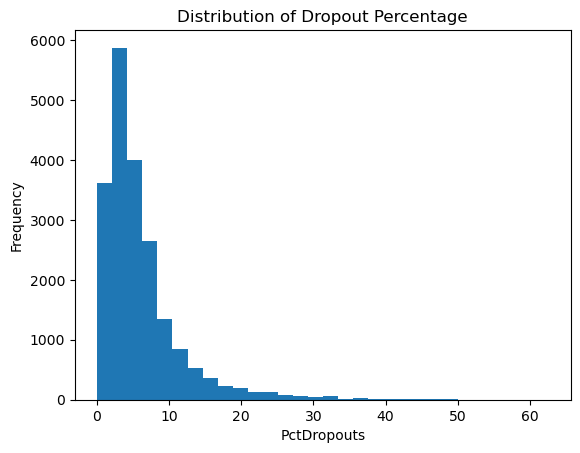

count    20293.000000
mean         6.222678
std          5.849409
min          0.100000
25%          2.600000
50%          4.500000
75%          7.600000
max         62.500000
Name: PctDropouts, dtype: float64

In [14]:
import matplotlib.pyplot as plt

plt.hist(df["PctDropouts"], bins=30)
plt.title("Distribution of Dropout Percentage")
plt.xlabel("PctDropouts")
plt.ylabel("Frequency")
plt.show()

df["PctDropouts"].describe()

The distribution of these dropout percentages follows a strongly skewed distribution, with most of the subgroups having lower dropout percentages, while a few have higher dropout percentages. The mean for these dropout percentages is approximately 6.22%, while the median for the dropout percentages is lower, at 4.5%. This also indicates that the distribution of these dropout percentages is affected by the higher-value outliers. Most of the subgroups are within the lower range of these dropout percentages, as indicated by the interquartile range, which includes a range from 2.6% (25th percentile) up to 7.6% (75th percentile). However, the maximum dropout rate goes as high as 62.5%. This indicates that, while the dropout rate is generally low, certain subgroups have significantly higher dropout rates.

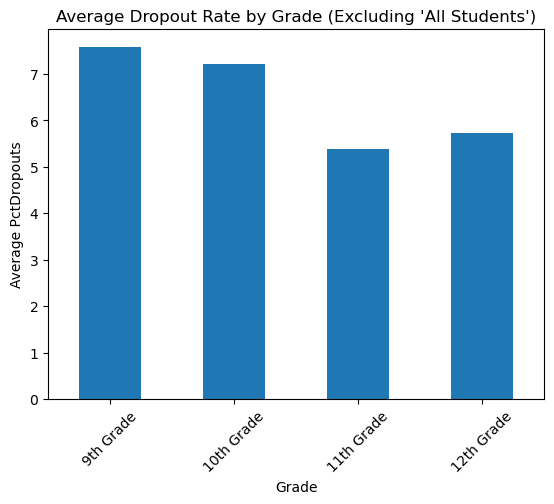

In [15]:
# Remove "All Students"
grade_df = df[df["Grade"] != "All Students"]

# Average dropout by grade
grade_avg = grade_df.groupby("Grade")["PctDropouts"].mean()

# Order grades
grade_order = ["9th Grade", "10th Grade", "11th Grade", "12th Grade"]
grade_avg = grade_avg.reindex(grade_order)

# Plot
plt.figure()
grade_avg.plot(kind="bar")

plt.title("Average Dropout Rate by Grade (Excluding 'All Students')")
plt.xlabel("Grade")
plt.ylabel("Average PctDropouts")
plt.xticks(rotation=45)

plt.show()

From the analysis of the dropout rate by grade, it can be observed that the rate tends to vary for different grade levels. In particular, the early grades of high school are observed to have higher dropout rates compared to later grades. This could imply that the dropout rate for high school tends to be higher in the early grades, making the grade level a significant factor in the model.